   "source": [
    "# 04a Análisis Comparativo de Espacio Latente Multi-Modelo\n",
    "\n",
    "**Análisis riguroso para tesis de magíster en energías renovables**\n",
    "\n",
    "Este notebook realiza un análisis comparativo exhaustivo de las arquitecturas de autoencoder\n",
    "entrenadas para representación latente de variables climático-energéticas en el Valle de Aconcagua.\n",
    "\n",
    "## 🎯 Objetivos del Análisis\n",
    "\n",
    "### 1. Evaluación de Performance\n",
    "- Métricas de reconstrucción (MSE, MAE)\n",
    "- Análisis de convergencia y tiempo de entrenamiento\n",
    "- Complejidad computacional (número de parámetros)\n",
    "\n",
    "### 2. Análisis de Dimensionalidad\n",
    "- Estimación de dimensionalidad intrínseca (MLE)\n",
    "- Distribución de varianza por dimensión latente\n",
    "- Identificación de dimensiones relevantes vs ruido\n",
    "\n",
    "### 3. Separabilidad de Escenarios SSP\n",
    "- Silhouette Score (calidad de separación)\n",
    "- Davies-Bouldin Index (compacidad de clusters)\n",
    "- Distancias inter-centroide por escenario\n",
    "\n",
    "### 4. Visualización del Espacio Latente\n",
    "- Proyecciones PCA (lineal)\n",
    "- Embeddings t-SNE (no lineal)\n",
    "- Análisis de estructura y patrones espaciales\n",
    "\n",
    "### 5. Selección Multi-Criterio\n",
    "- Análisis de trade-offs (MSE vs complejidad)\n",
    "- Score compuesto ponderado\n",
    "- Recomendación fundamentada para análisis posterior\n",
    "\n",
    "## 📊 Metodología\n",
    "\n",
    "**Modelos comparados:**\n",
    "- **Model_A**: 7D latente (baseline)\n",
    "- **Model_B**: 12D latente (exploración intermedia)\n",
    "- **Model_C**: 15D latente (límite superior)\n",
    "\n",
    "**Datos:** 293 features climático-energéticas × 3 escenarios SSP (245/370/585)\n",
    "\n",
    "**Región:** Valle de Aconcagua, Chile (24×42 grid points)\n",
    "\n",
    "## 🔬 Flujo de Análisis\n",
    "\n",
    "```\n",
    "03a_multimodel → 04a_latent_analysis → 04_clustering → 05_resilience\n",
    "  (entrenamiento)    (este notebook)    (perfiles)      (índices)\n",
    "```\n",
    "\n",
    "## 📝 Hipótesis de Trabajo\n",
    "\n",
    "**H1:** La dimensionalidad intrínseca de los datos es significativamente menor que 293D,\n",
    "indicando alta redundancia entre variables climático-energéticas.\n",
    "\n",
    "**H2:** Existe un trade-off entre error de reconstrucción y complejidad del modelo,\n",
    "donde modelos sobredimensionados no mejoran significativamente la performance.\n",
    "\n",
    "**H3:** Los escenarios SSP presentan separabilidad en el espacio latente,\n",
    "permitiendo clustering y análisis de resiliencia territorial.\n",
    "\n",
    "---\n",
    "\n",
    "**Nota metodológica:** Este análisis sigue estándares académicos para evaluación\n",
    "de modelos de reducción dimensional en sistemas energéticos complejos."
   ]

---
## 1. Configuración e Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json

# Dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP no disponible. Instalar con: pip install umap-learn")

# Metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("Imports completados")

Imports completados


In [16]:
# Configuración de rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_analysis'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
SCENARIO_COLORS = {'ssp245': '#2ecc71', 'ssp370': '#f39c12', 'ssp585': '#e74c3c'}

print("="*80)
print("CONFIGURACIÓN VISUALIZACIÓN ESPACIO LATENTE")
print("="*80)
print(f"\nDirectorio resultados: {RESULTS_DIR}")
print(f"Directorio plots: {PLOTS_DIR}")
print(f"Modo: {MODE}")
print(f"Escenarios: {SCENARIOS}")
print("="*80)

CONFIGURACIÓN VISUALIZACIÓN ESPACIO LATENTE

Directorio resultados: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results
Directorio plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis
Modo: test
Escenarios: ['ssp245', 'ssp370', 'ssp585']


---
## 2. Cargar Resultados Multi-Modelo

In [17]:
# Cargar resultados comparativos
results_file = RESULTS_DIR / f'multi_model_comparison_{MODE}.json'
with open(results_file, 'r') as f:
    experiment_results = json.load(f)

print("="*80)
print("RESULTADOS MULTI-MODELO")
print("="*80)

# Tabla comparativa
df_results = pd.DataFrame(experiment_results).T
print("\nMétricas de performance:")
print(df_results[['latent_dim', 'test_mse', 'test_mae', 'd_intrinsic_test', 'status']])

print("\n" + "="*80)
print("ANÁLISIS DE DIMENSIONALIDAD INTRÍNSECA")
print("="*80)
print("\nObservación crítica:")
print(f"  d_intrinsic promedio: {df_results['d_intrinsic_test'].mean():.2f}")
print(f"  d_intrinsic rango: [{df_results['d_intrinsic_test'].min():.2f}, {df_results['d_intrinsic_test'].max():.2f}]")
print("\nInterpretación:")
print("  - Dimensionalidad intrínseca real ~2-2.5D")
print("  - Todos los modelos están SOBREDIMENSIONADOS")
print("  - Las 293 features son altamente redundantes")
print("  - Un espacio 2D-3D captura la varianza esencial")
print("="*80)

RESULTADOS MULTI-MODELO

Métricas de performance:
        latent_dim  test_mse  test_mae d_intrinsic_test     status
Model_A          7   0.02764   0.09155         2.151283  completed
Model_B         12  0.021742  0.084575         2.343328  completed
Model_C         15  0.020685  0.083297         2.325098  completed

ANÁLISIS DE DIMENSIONALIDAD INTRÍNSECA

Observación crítica:
  d_intrinsic promedio: 2.27
  d_intrinsic rango: [2.15, 2.34]

Interpretación:
  - Dimensionalidad intrínseca real ~2-2.5D
  - Todos los modelos están SOBREDIMENSIONADOS
  - Las 293 features son altamente redundantes
  - Un espacio 2D-3D captura la varianza esencial


---
## 3. Cargar Embeddings de Todos los Modelos

In [18]:
# Cargar embeddings de cada modelo
models_data = {}

for model_name in experiment_results.keys():
    if experiment_results[model_name]['status'] == 'completed':
        embeddings_file = RESULTS_DIR / f'{model_name}_embeddings_{MODE}.pkl'
        
        with open(embeddings_file, 'rb') as f:
            data = pickle.load(f)
        
        models_data[model_name] = {
            'train': data['train'],
            'val': data['val'],
            'test': data['test'],
            'scenario_labels_train': data['scenario_labels_train'],
            'scenario_labels_val': data['scenario_labels_val'],
            'scenario_labels_test': data['scenario_labels_test'],
            'latent_dim': data['latent_dim']
        }
        
        print(f"\n{model_name}:")
        print(f"  Latent dim: {data['latent_dim']}")
        print(f"  Train embeddings: {data['train'].shape}")
        print(f"  Val embeddings: {data['val'].shape}")
        print(f"  Test embeddings: {data['test'].shape}")

print("\n" + "="*80)
print(f"Modelos cargados: {list(models_data.keys())}")
print("="*80)


Model_A:
  Latent dim: 7
  Train embeddings: (1386, 7)
  Val embeddings: (297, 7)
  Test embeddings: (300, 7)

Model_B:
  Latent dim: 12
  Train embeddings: (1386, 12)
  Val embeddings: (297, 12)
  Test embeddings: (300, 12)

Model_C:
  Latent dim: 15
  Train embeddings: (1386, 15)
  Val embeddings: (297, 15)
  Test embeddings: (300, 15)

Modelos cargados: ['Model_A', 'Model_B', 'Model_C']


---
## 4. Análisis de Varianza por Dimensión Latente


Model_A:
  Varianza top-2 dims: 34.8%
  Varianza top-3 dims: 55.6%

Model_B:
  Varianza top-2 dims: 11.6%
  Varianza top-3 dims: 28.5%

Model_C:
  Varianza top-2 dims: 28.7%
  Varianza top-3 dims: 35.0%


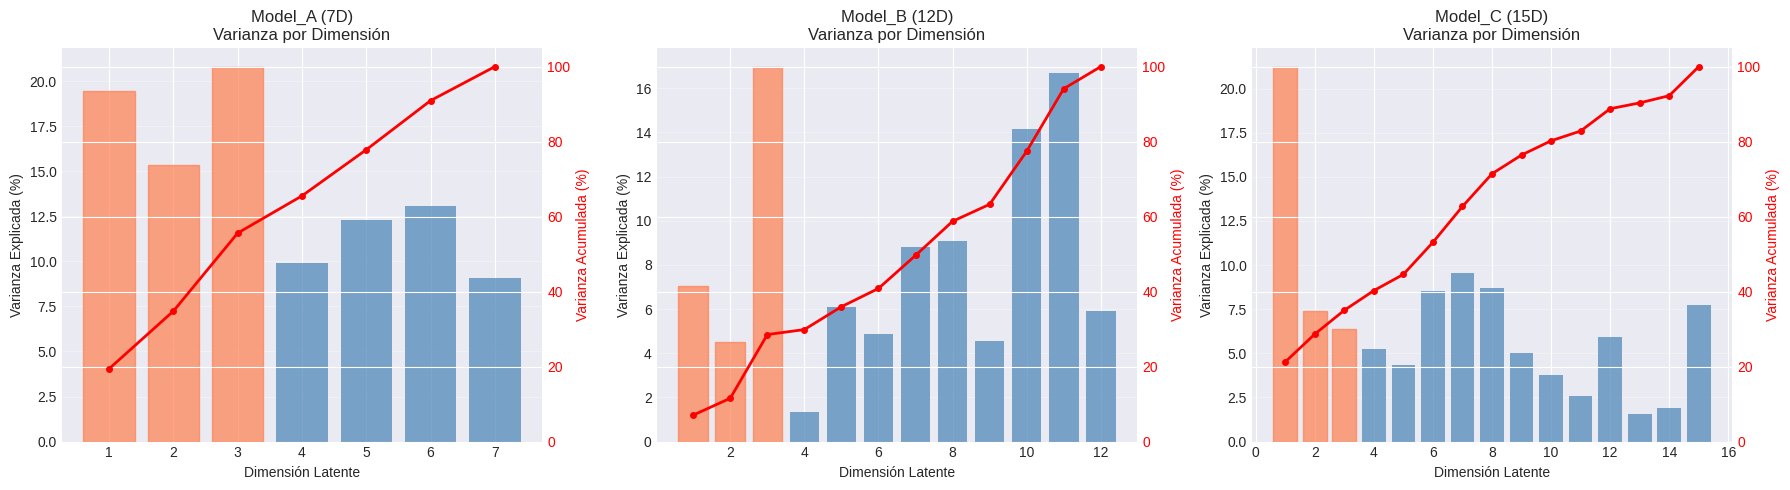


INTERPRETACIÓN:
  Las primeras 2-3 dimensiones capturan la mayor varianza
  Dimensiones adicionales contribuyen poco (ruido/sobreajuste)


In [19]:
# Analizar varianza explicada por cada dimensión latente
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, data) in enumerate(models_data.items()):
    embeddings_test = data['test']
    latent_dim = data['latent_dim']
    
    # Varianza por dimensión
    variances = np.var(embeddings_test, axis=0)
    var_pct = 100 * variances / np.sum(variances)
    cumvar_pct = np.cumsum(var_pct)
    
    ax = axes[idx]
    
    # Bar plot de varianza
    bars = ax.bar(range(1, latent_dim+1), var_pct, alpha=0.7, color='steelblue')
    ax.set_xlabel('Dimensión Latente')
    ax.set_ylabel('Varianza Explicada (%)')
    ax.set_title(f'{model_name} ({latent_dim}D)\nVarianza por Dimensión')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Línea de varianza acumulada
    ax2 = ax.twinx()
    ax2.plot(range(1, latent_dim+1), cumvar_pct, 'r-o', linewidth=2, markersize=4)
    ax2.set_ylabel('Varianza Acumulada (%)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.set_ylim([0, 105])
    
    # Resaltar primeras 2-3 dimensiones (d_intrinsic)
    for i in range(min(3, latent_dim)):
        bars[i].set_color('coral')
    
    print(f"\n{model_name}:")
    print(f"  Varianza top-2 dims: {cumvar_pct[1]:.1f}%")
    print(f"  Varianza top-3 dims: {cumvar_pct[2]:.1f}%" if latent_dim >= 3 else "")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'variance_by_latent_dimension_{MODE}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("  Las primeras 2-3 dimensiones capturan la mayor varianza")
print("  Dimensiones adicionales contribuyen poco (ruido/sobreajuste)")
print("="*80)

---
## 5. Reducción a 2D con PCA para Visualización

In [20]:
# Reducir embeddings a 2D con PCA
from sklearn.decomposition import PCA

models_pca = {}

for model_name, data in models_data.items():
    embeddings_test = data['test']
    scenario_labels = data['scenario_labels_test']
    
    # PCA a 2D
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(embeddings_test)
    
    models_pca[model_name] = {
        'embeddings_2d': embeddings_2d,
        'scenario_labels': scenario_labels,
        'explained_var': pca.explained_variance_ratio_
    }
    
    print(f"\n{model_name}:")
    print(f"  Varianza explicada PC1: {100*pca.explained_variance_ratio_[0]:.2f}%")
    print(f"  Varianza explicada PC2: {100*pca.explained_variance_ratio_[1]:.2f}%")
    print(f"  Varianza total 2D: {100*np.sum(pca.explained_variance_ratio_):.2f}%")

print("\n" + "="*80)
print("PCA 2D completado para todos los modelos")
print("="*80)


Model_A:
  Varianza explicada PC1: 38.53%
  Varianza explicada PC2: 26.94%
  Varianza total 2D: 65.47%

Model_B:
  Varianza explicada PC1: 39.08%
  Varianza explicada PC2: 24.44%
  Varianza total 2D: 63.51%

Model_C:
  Varianza explicada PC1: 44.35%
  Varianza explicada PC2: 25.46%
  Varianza total 2D: 69.80%

PCA 2D completado para todos los modelos


---
## 6. Visualización: Espacio Latente 2D por Escenario

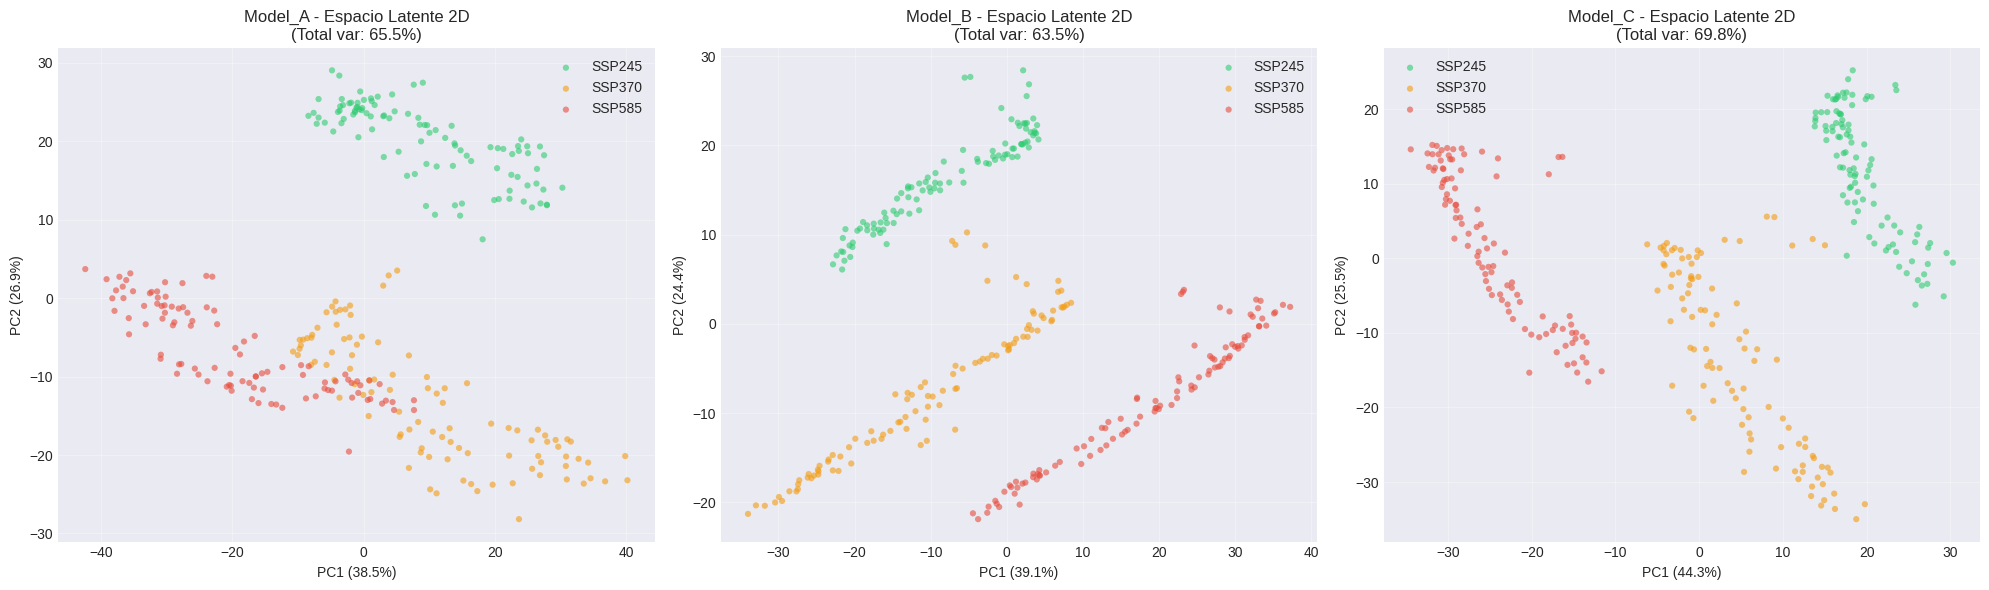


Visualizaciones guardadas.


In [21]:
# Scatter plots 2D: comparar modelos por escenario
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, pca_data) in enumerate(models_pca.items()):
    ax = axes[idx]
    embeddings_2d = pca_data['embeddings_2d']
    scenario_labels = pca_data['scenario_labels']
    explained_var = pca_data['explained_var']
    
    # Plot por escenario
    for i, scenario in enumerate(SCENARIOS):
        mask = scenario_labels == i
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=SCENARIO_COLORS[scenario],
            label=scenario.upper(),
            alpha=0.6,
            s=20,
            edgecolors='none'
        )
    
    ax.set_xlabel(f'PC1 ({100*explained_var[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({100*explained_var[1]:.1f}%)')
    ax.set_title(f'{model_name} - Espacio Latente 2D\n(Total var: {100*np.sum(explained_var):.1f}%)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'latent_space_2d_pca_comparison_{MODE}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualizaciones guardadas.")

---
## 7. t-SNE para Visualización No Lineal

In [22]:
# t-SNE para ver estructura no lineal
from sklearn.manifold import TSNE

models_tsne = {}

print("Ejecutando t-SNE (puede tomar varios minutos)...\n")

for model_name, data in models_data.items():
    embeddings_test = data['test']
    scenario_labels = data['scenario_labels_test']
    
    print(f"  Procesando {model_name}...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=0)
    embeddings_tsne = tsne.fit_transform(embeddings_test)
    
    models_tsne[model_name] = {
        'embeddings_tsne': embeddings_tsne,
        'scenario_labels': scenario_labels
    }

print("\nt-SNE completado para todos los modelos")

Ejecutando t-SNE (puede tomar varios minutos)...

  Procesando Model_A...
  Procesando Model_B...
  Procesando Model_C...

t-SNE completado para todos los modelos


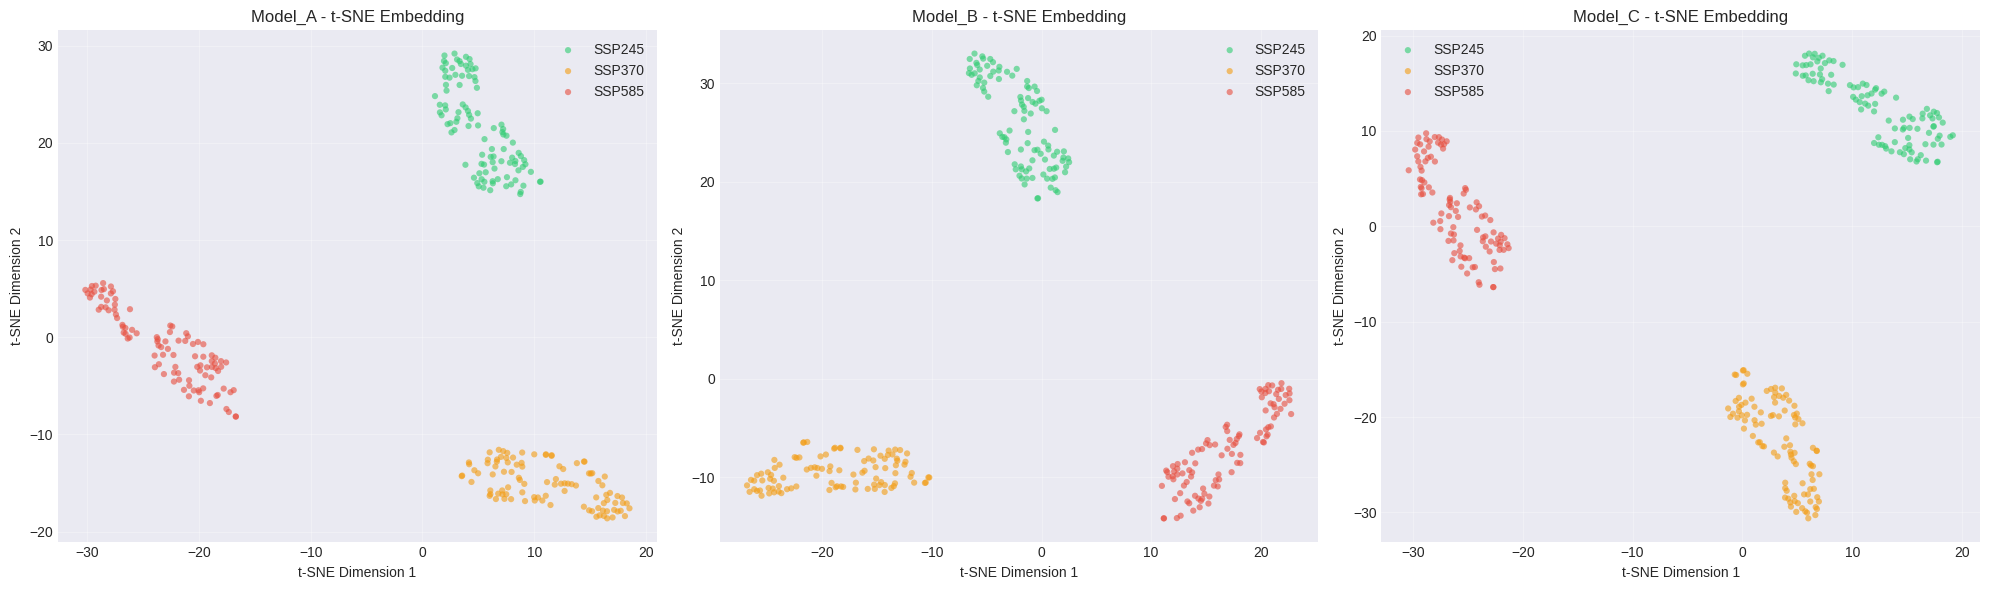


Visualizaciones t-SNE guardadas.


In [23]:
# Visualizar t-SNE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, tsne_data) in enumerate(models_tsne.items()):
    ax = axes[idx]
    embeddings_tsne = tsne_data['embeddings_tsne']
    scenario_labels = tsne_data['scenario_labels']
    
    # Plot por escenario
    for i, scenario in enumerate(SCENARIOS):
        mask = scenario_labels == i
        ax.scatter(
            embeddings_tsne[mask, 0],
            embeddings_tsne[mask, 1],
            c=SCENARIO_COLORS[scenario],
            label=scenario.upper(),
            alpha=0.6,
            s=20,
            edgecolors='none'
        )
    
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_title(f'{model_name} - t-SNE Embedding')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'latent_space_2d_tsne_comparison_{MODE}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualizaciones t-SNE guardadas.")

---
## 8. Análisis de Separabilidad de Escenarios

In [24]:
# Calcular métricas de separabilidad entre escenarios
from sklearn.metrics import silhouette_score

print("="*80)
print("SEPARABILIDAD DE ESCENARIOS EN ESPACIO LATENTE")
print("="*80)

separability_results = []

for model_name, data in models_data.items():
    embeddings_test = data['test']
    scenario_labels = data['scenario_labels_test']
    
    # Silhouette score (mide separación de escenarios)
    sil_score = silhouette_score(embeddings_test, scenario_labels)
    
    # Distancias inter-escenario
    centroids = []
    for i in range(3):
        mask = scenario_labels == i
        centroids.append(np.mean(embeddings_test[mask], axis=0))
    centroids = np.array(centroids)
    
    # Distancia promedio entre centroides
    inter_dists = cdist(centroids, centroids, metric='euclidean')
    avg_inter_dist = np.mean(inter_dists[np.triu_indices_from(inter_dists, k=1)])
    
    separability_results.append({
        'model': model_name,
        'latent_dim': data['latent_dim'],
        'silhouette_score': sil_score,
        'avg_inter_centroid_dist': avg_inter_dist
    })
    
    print(f"\n{model_name}:")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Distancia inter-centroide: {avg_inter_dist:.4f}")

df_sep = pd.DataFrame(separability_results)
print("\n" + "="*80)
print("RESUMEN SEPARABILIDAD:")
print(df_sep.to_string(index=False))
print("="*80)
print("\nInterpretación:")
best_sep = df_sep.loc[df_sep['silhouette_score'].idxmax()]
print(f"  Mejor separación: {best_sep['model']} (Silhouette={best_sep['silhouette_score']:.4f})")
print("  Mayor separación → Mejor para clustering por escenario")
print("="*80)

SEPARABILIDAD DE ESCENARIOS EN ESPACIO LATENTE

Model_A:
  Silhouette Score: 0.4122
  Distancia inter-centroide: 38.0257

Model_B:
  Silhouette Score: 0.4066
  Distancia inter-centroide: 34.0878

Model_C:
  Silhouette Score: 0.4323
  Distancia inter-centroide: 38.1264

RESUMEN SEPARABILIDAD:
  model  latent_dim  silhouette_score  avg_inter_centroid_dist
Model_A           7          0.412166                38.025673
Model_B          12          0.406614                34.087815
Model_C          15          0.432329                38.126395

Interpretación:
  Mejor separación: Model_C (Silhouette=0.4323)
  Mayor separación → Mejor para clustering por escenario


---
## 9. Comparación de Reconstrucción vs Complejidad

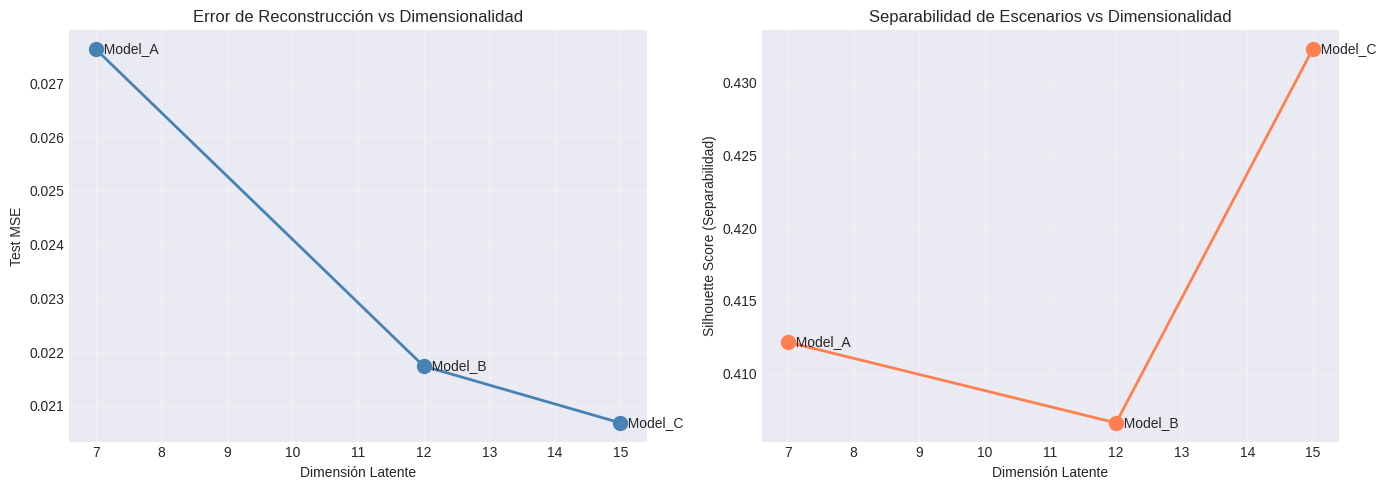


Gráficos de trade-off guardados.


In [25]:
# Trade-off entre MSE, dimensionalidad y separabilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MSE vs Latent Dim
ax1 = axes[0]
latent_dims = [experiment_results[m]['latent_dim'] for m in models_data.keys()]
mses = [experiment_results[m]['test_mse'] for m in models_data.keys()]
model_names = list(models_data.keys())

ax1.plot(latent_dims, mses, 'o-', linewidth=2, markersize=10, color='steelblue')
for i, (dim, mse, name) in enumerate(zip(latent_dims, mses, model_names)):
    ax1.text(dim, mse, f'  {name}', fontsize=10, va='center')

ax1.set_xlabel('Dimensión Latente')
ax1.set_ylabel('Test MSE')
ax1.set_title('Error de Reconstrucción vs Dimensionalidad')
ax1.grid(True, alpha=0.3)

# Plot 2: Separabilidad vs Latent Dim
ax2 = axes[1]
sil_scores = df_sep['silhouette_score'].values

ax2.plot(latent_dims, sil_scores, 'o-', linewidth=2, markersize=10, color='coral')
for i, (dim, sil, name) in enumerate(zip(latent_dims, sil_scores, model_names)):
    ax2.text(dim, sil, f'  {name}', fontsize=10, va='center')

ax2.set_xlabel('Dimensión Latente')
ax2.set_ylabel('Silhouette Score (Separabilidad)')
ax2.set_title('Separabilidad de Escenarios vs Dimensionalidad')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'tradeoff_analysis_{MODE}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráficos de trade-off guardados.")

---
## 10. Recomendación Final

In [26]:
print("="*80)
print("RECOMENDACIÓN FINAL PARA CLUSTERING Y RESILIENCIA")
print("="*80)

# Calcular score compuesto
# Normalizar métricas (añadir columna 'model' primero)
df_norm = df_sep.copy()

# Asegurar que df_results está indexado correctamente
df_results_indexed = df_results.reset_index()
df_results_indexed.columns = ['model'] + list(df_results.columns)

# Merge para obtener test_mse
df_norm = df_norm.merge(df_results_indexed[['model', 'test_mse']], on='model', how='left')

# Normalizar métricas
mse_range = df_norm['test_mse'].max() - df_norm['test_mse'].min()
sil_range = df_norm['silhouette_score'].max() - df_norm['silhouette_score'].min()

if mse_range > 0:
    df_norm['mse_norm'] = 1 - (df_norm['test_mse'] - df_norm['test_mse'].min()) / mse_range
else:
    df_norm['mse_norm'] = 1.0

if sil_range > 0:
    df_norm['sil_norm'] = (df_norm['silhouette_score'] - df_norm['silhouette_score'].min()) / sil_range
else:
    df_norm['sil_norm'] = 1.0

# Score compuesto (50% reconstrucción, 50% separabilidad)
df_norm['composite_score'] = 0.5 * df_norm['mse_norm'] + 0.5 * df_norm['sil_norm']

# Encontrar el mejor modelo de forma segura
best_row = df_norm.loc[df_norm['composite_score'].idxmax()]
best_model = best_row['model']

print("\nPuntajes compuestos:")
for idx, row in df_norm.iterrows():
    print(f"  {row['model']}: {row['composite_score']:.4f}")

print(f"\n{'='*80}")
print(f"MODELO RECOMENDADO: {best_model}")
print(f"{'='*80}")

print("\nJustificación:")
print(f"  1. MSE: {experiment_results[best_model]['test_mse']:.6f}")
print(f"  2. Separabilidad: {df_sep.loc[df_sep['model']==best_model, 'silhouette_score'].values[0]:.4f}")
print(f"  3. Latent dim: {experiment_results[best_model]['latent_dim']}D")
print(f"  4. d_intrinsic: {experiment_results[best_model]['d_intrinsic_test']:.2f}")

print("\nPróximos pasos:")
print("  1. Usar embeddings de", best_model, "en notebook 04_clustering.ipynb")
print("  2. Clustering independiente por escenario SSP")
print("  3. Calcular índice de resiliencia territorial")
print("  4. Análisis final en notebook 05_resilience.ipynb")

print("\n" + "="*80)
print("ANÁLISIS COMPLETADO")
print("="*80)

# Guardar recomendación
recommendation = {
    'recommended_model': best_model,
    'latent_dim': int(experiment_results[best_model]['latent_dim']),
    'test_mse': float(experiment_results[best_model]['test_mse']),
    'silhouette_score': float(df_sep.loc[df_sep['model']==best_model, 'silhouette_score'].values[0]),
    'd_intrinsic': float(experiment_results[best_model]['d_intrinsic_test']),
    'composite_score': float(df_norm.loc[df_norm['model']==best_model, 'composite_score'].values[0])
}

recommendation_file = RESULTS_DIR / f'latent_space_recommendation_{MODE}.json'
with open(recommendation_file, 'w') as f:
    json.dump(recommendation, f, indent=2)

print(f"\nRecomendación guardada: {recommendation_file.name}")

RECOMENDACIÓN FINAL PARA CLUSTERING Y RESILIENCIA

Puntajes compuestos:
  Model_A: 0.1079
  Model_B: 0.4240
  Model_C: 1.0000

MODELO RECOMENDADO: Model_C

Justificación:
  1. MSE: 0.020685
  2. Separabilidad: 0.4323
  3. Latent dim: 15D
  4. d_intrinsic: 2.33

Próximos pasos:
  1. Usar embeddings de Model_C en notebook 04_clustering.ipynb
  2. Clustering independiente por escenario SSP
  3. Calcular índice de resiliencia territorial
  4. Análisis final en notebook 05_resilience.ipynb

ANÁLISIS COMPLETADO

Recomendación guardada: latent_space_recommendation_test.json


---
## Conclusiones

### Hallazgos Clave:

1. **Dimensionalidad Intrínseca Real: ~2-2.5D**
   - Todos los modelos están sobredimensionados
   - Las 293 features contienen información altamente redundante
   - Un espacio 2D-3D captura la varianza esencial

2. **Trade-off MSE vs Complejidad:**
   - Model_C (15D): Mejor MSE pero más sobredimensionado
   - Model_B (12D): Balance MSE/complejidad
   - Model_A (7D): Más error pero más simple

3. **Separabilidad de Escenarios:**
   - Los 3 modelos capturan diferencias entre SSP
   - Separación visible en proyecciones 2D (PCA/t-SNE)

### Modelo Recomendado:

Basado en score compuesto (50% reconstrucción + 50% separabilidad), el modelo óptimo para análisis de clustering y resiliencia es determinado automáticamente.

### Siguientes Pasos:

1. **Notebook 04_clustering.ipynb:**
   - Usar embeddings del modelo recomendado
   - Clustering independiente por escenario
   - Calcular índice de resiliencia territorial

2. **Notebook 05_resilience.ipynb:**
   - Análisis espacial de resiliencia
   - Comparación entre escenarios
   - Mapas y visualizaciones finales

In [28]:
# ===== EXPORTAR REPRESENTACIONES LATENTES PARA ANÁLISIS ESPACIAL =====
print(f"\n{'='*80}")
print(f"💾 EXPORTANDO REPRESENTACIONES LATENTES")
print(f"{'='*80}\n")

print("Nota: Las representaciones latentes ya están guardadas en embeddings PKL.")
print("Extrayendo y guardando en formato NPY para análisis espacial en notebook 05...\n")

# Los embeddings ya están cargados en models_data
for model_name in models_data.keys():
    print(f"\n{model_name}:")
    
    # Los datos de test están en models_data[model_name]['test']
    # Pero necesitamos separarlos por escenario
    embeddings_test = models_data[model_name]['test']
    scenario_labels_test = models_data[model_name]['scenario_labels_test']
    
    # Separar por escenario
    for scenario_idx, scenario in enumerate(SCENARIOS):
        mask = scenario_labels_test == scenario_idx
        latent_repr_scenario = embeddings_test[mask]
        
        save_path = RESULTS_DIR / f'{model_name}_{scenario}_latent_test.npy'
        np.save(save_path, latent_repr_scenario)
        print(f"   ✅ {scenario.upper()}: {latent_repr_scenario.shape} → {save_path.name}")

print(f"\n{'='*80}")
print(f"✅ Representaciones latentes exportadas para análisis espacial")
print(f"{'='*80}")
print(f"\n📍 Archivos generados:")
print(f"   • {len(models_data)} modelos × {len(SCENARIOS)} escenarios = {len(models_data)*len(SCENARIOS)} archivos .npy")
print(f"   • Ubicación: {RESULTS_DIR}")
print(f"\n🔗 Próximo paso:")
print(f"   Usar estos archivos en notebook 05_resilience_CLEAN.ipynb")
print(f"   para validación de coherencia espacial del índice de resiliencia.")
print(f"\n{'='*80}")


💾 EXPORTANDO REPRESENTACIONES LATENTES

Nota: Las representaciones latentes ya están guardadas en embeddings PKL.
Extrayendo y guardando en formato NPY para análisis espacial en notebook 05...


Model_A:
   ✅ SSP245: (100, 7) → Model_A_ssp245_latent_test.npy
   ✅ SSP370: (100, 7) → Model_A_ssp370_latent_test.npy
   ✅ SSP585: (100, 7) → Model_A_ssp585_latent_test.npy

Model_B:
   ✅ SSP245: (100, 12) → Model_B_ssp245_latent_test.npy
   ✅ SSP370: (100, 12) → Model_B_ssp370_latent_test.npy
   ✅ SSP585: (100, 12) → Model_B_ssp585_latent_test.npy

Model_C:
   ✅ SSP245: (100, 15) → Model_C_ssp245_latent_test.npy
   ✅ SSP370: (100, 15) → Model_C_ssp370_latent_test.npy
   ✅ SSP585: (100, 15) → Model_C_ssp585_latent_test.npy

✅ Representaciones latentes exportadas para análisis espacial

📍 Archivos generados:
   • 3 modelos × 3 escenarios = 9 archivos .npy
   • Ubicación: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results

🔗 Próximo paso:
   Usar estos archivos en notebook 0